# Notebook 5 — Clustering into units

*SWC ENC 2026 · ephys-pop module*

In the feature space, each neuron is a cloud of points. **Clustering** turns those
clouds into labelled **units**, with no ground-truth labels to guide it — this is
the unsupervised heart of spike sorting. Then we average each cluster's snippets into
a **template**: the unit's canonical spike, the thing matching pursuit will hunt for
in Notebook 6.

**In this notebook you will:**
1. Decide **how many units** there are, using the BIC.
2. **Cluster** the spikes with a Gaussian mixture.
3. Average each cluster into a **template** and check it against the truth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picosort as ps

rec = ps.make_recording(n_units=6, duration_s=20.0, seed=0)
whitened, filtered, W = ps.preprocess(rec)
times, peak_channels = ps.detect_spikes(whitened, rec.probe, rec.fs, threshold=5.0)
snippets, times = ps.extract_snippets(filtered, times, peak_channels=peak_channels)
features, parts = ps.spike_features(snippets, rec.probe)

# Drop tiny threshold crossings: below ~100 µV they're noise and collision fragments,
# not real spikes. This keeps the clustering clean.
keep = parts["amplitude"] > 100
features, snippets = features[keep], snippets[keep]
times, depth, amplitude = times[keep], parts["depth"][keep], parts["amplitude"][keep]
print(f"{len(times)} spikes kept for clustering")

398 spikes kept for clustering


## 1. How many units? The BIC

Clustering needs to know how many clusters to look for, and we don't — that's part of
what we're trying to discover. One principled answer: fit a **Gaussian mixture** for
each candidate count $k$ and score it by the **Bayesian Information Criterion (BIC)**,
which rewards fit but penalises extra clusters. The BIC falls steeply as $k$ climbs
toward the true number, then flattens — the **elbow** marks how many units are really
there.

<details>
<summary><b>▸ Go deeper: Gaussian mixtures, and where the BIC comes from (optional)</b></summary>

**The model.** A Gaussian mixture says each spike's feature vector $x$ was drawn from
one of $k$ Gaussians — one per unit — with unknown mixing weights $\pi_j$, means
$\mu_j$, and covariances $\Sigma_j$:

$$p(x \mid \theta) = \sum_{j=1}^{k} \pi_j\, \mathcal{N}(x;\, \mu_j, \Sigma_j).$$

We fit $\theta$ by maximising the log-likelihood $\log \hat L = \sum_i \log p(x_i\mid\theta)$,
using the **EM algorithm**: alternate between the **E-step** (compute each spike's
*responsibility* — the posterior probability it belongs to unit $j$) and the
**M-step** (re-estimate each $\pi_j, \mu_j, \Sigma_j$ as responsibility-weighted
averages). This is a soft version of the assign-then-average loop you already know.
(k-means is the special case with equal spherical $\Sigma_j = \sigma^2 I$ and *hard*
responsibilities — which is exactly why it merges close clusters and splits elongated
ones, and why the full mixture does better here.)

**The penalty.** More clusters always fit better, so raw likelihood can't choose $k$.
The BIC adds a complexity penalty:

$$\mathrm{BIC}(k) = -2\log \hat L \;+\; m_k \log n,$$

with $m_k$ the number of free parameters and $n$ the number of spikes. It is a
large-$n$ approximation (via **Laplace's method**) to $-2\log p(\text{data}\mid k)$,
the *model evidence* — the same Bayesian quantity that decided "which strategies
matter" in the behaviour module, here deciding "how many neurons are there." Extra
clusters beyond the truth buy almost no likelihood but keep paying $\log n$ per
parameter, so the curve flattens: the **elbow is the honest unit count.**
</details>

**Exercise 1** *(~5 min)*. Compute the BIC curve over `k = 2..10` and read off the elbow.

> **Check / unstuck.** The curve should drop hard through **k = 6**, then level off.
> Stuck? Use `ps.bic_curve(features)`.

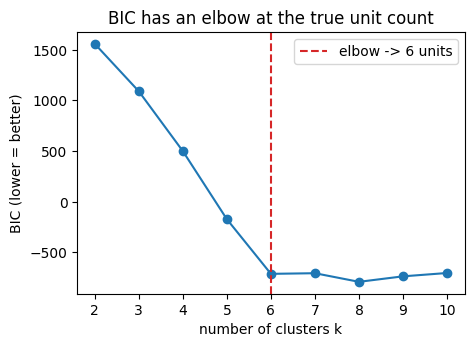

In [2]:
from sklearn.mixture import GaussianMixture

def bic_curve(features, k_values=range(2, 11)):
    return {k: GaussianMixture(k, n_init=5, random_state=0).fit(features).bic(features)
            for k in k_values}

bics = bic_curve(features)
ks = list(bics); vals = list(bics.values())
plt.figure(figsize=(5, 3.4))
plt.plot(ks, vals, "o-"); plt.axvline(6, color="tab:red", ls="--", label="elbow -> 6 units")
plt.xlabel("number of clusters k"); plt.ylabel("BIC (lower = better)")
plt.legend(); plt.title("BIC has an elbow at the true unit count"); plt.show()

## 2. Cluster with a Gaussian mixture

With $k = 6$, fit a **Gaussian mixture**: it models each unit as an ellipse in
feature space and assigns every spike to the most likely one. (A Gaussian mixture
handles clusters of different size and shape, where simpler k-means would merge two
close units and split a third.)

**Exercise 2** *(~4 min · easy)*. Fit the mixture and assign labels.

> **Check / unstuck.** You should get 6 clusters that match the clouds by eye. Stuck?
> Use `ps.cluster_spikes(features, 6)`.

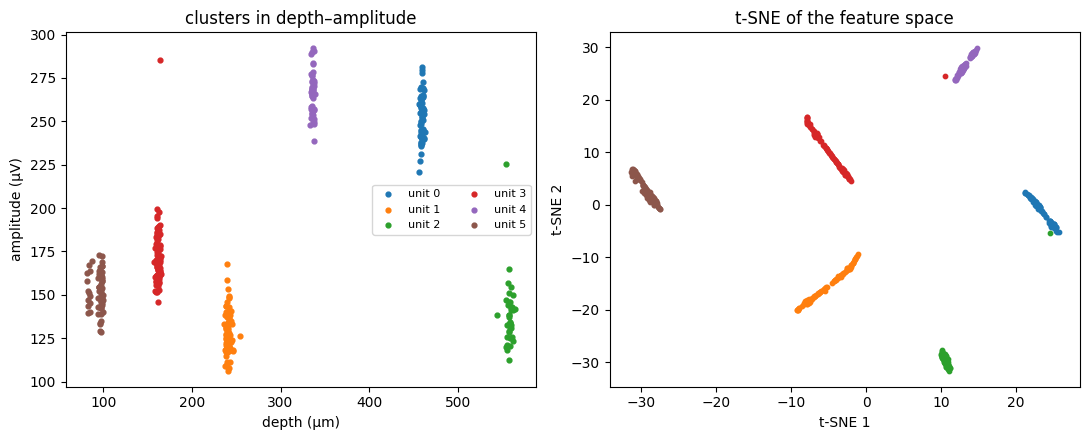

In [3]:
labels = GaussianMixture(6, n_init=10, random_state=0).fit_predict(features)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ps.plotting.plot_feature_space(depth, amplitude, labels, ax=axes[0],
                               title="clusters in depth–amplitude")
emb = ps.tsne_embedding(features)
for u in np.unique(labels):
    m = labels == u
    axes[1].scatter(emb[m, 0], emb[m, 1], s=10, color=ps.plotting.unit_color(int(u)))
axes[1].set_title("t-SNE of the feature space"); axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
plt.tight_layout(); plt.show()

The **t-SNE** plot is a QC tool: it squashes the feature space to 2-D so you can
eyeball whether the clusters are genuinely separate blobs (good) or smeared into each
other (a warning). Here they're clean, well-isolated islands.

## 3. From clusters to templates

A **template** is the average of a cluster's snippets — the same noise-averages-away
trick from Notebook 1, but now with clusters we *discovered* instead of labels we
were handed. Average each cluster's multichannel snippets to get one template per
unit.

**Exercise 3** *(~5 min)*. Complete `templates_from_labels`: for each label, average its
snippets into a `(n_channels, n_samples)` template.

> **Check / unstuck.** You should get 6 templates, each a clean footprint at a
> distinct depth. Stuck? Use `ps.templates_from_labels(snippets, labels)`.

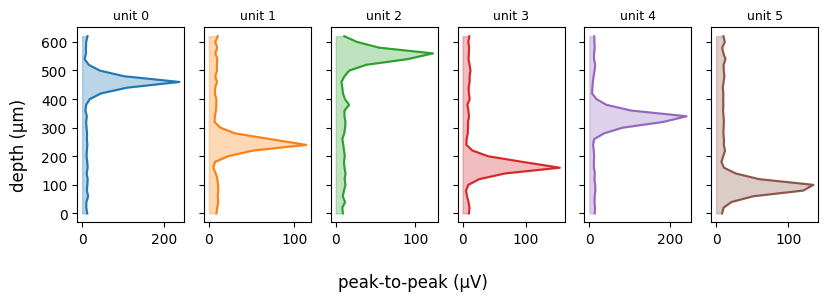

In [4]:
def templates_from_labels(snippets, labels):
    ids = np.array(sorted(u for u in np.unique(labels) if u >= 0))
    templates = np.stack([snippets[labels == u].mean(axis=0) for u in ids])
    return templates, ids

templates, ids = templates_from_labels(snippets, labels)
ps.plotting.plot_templates(templates, rec.probe)
plt.show()

## 4. Did we recover the real units?

Because this is synthetic data, we can check. Match each learned template to the
true template it most resembles and compare their shapes — they should be nearly
identical, up to noise.

In [5]:
gt = rec.ground_truth
corr = np.zeros((len(templates), gt.n_units))
for a in range(len(templates)):
    for b in range(gt.n_units):
        corr[a, b] = np.corrcoef(templates[a].ravel(), gt.templates[b].ravel())[0, 1]
best = corr.max(axis=1)
print("each learned template's correlation to its best-matching true template:")
print(np.round(best, 3))
print(f"worst match: {best.min():.3f}  ->  all six units recovered" if best.min() > 0.8
      else f"worst match: {best.min():.3f}")

each learned template's correlation to its best-matching true template:
[0.969 0.929 0.923 0.947 0.965 0.918]
worst match: 0.918  ->  all six units recovered


## Wrap-up

You found the number of units from the BIC elbow, clustered the spikes with a
Gaussian mixture, and averaged each cluster into a template that matches a real
neuron. We now have a template per unit — but clustering assigned each spike to
*exactly one* unit, which breaks down when two spikes **overlap**.

**Next (Notebook 6 — matching pursuit):** use the templates to pull apart overlapping
spikes, the collisions clustering can't handle.